# NEOMOD3 VDP — final held-out TEST review

**This is a review notebook, not an experiment.** Nothing here is selected, tuned, or refit. It
reproduces the frozen TEST result from sealed artifacts and explains it.

TEST was held **sealed** — not drawn, not inspected — until three things were frozen on CAL:

1. **interpolation variant C** (density-first velocity + magnitude interpolation, nearest sky cell)
2. **Platt calibration** `P_cal = sigmoid(a·logit(P_raw) + b)`
3. **operating thresholds**, chosen on CAL and applied to TEST **unchanged**

Those choices are recorded in `MODEL_SEAL.json`, whose SHA256 is verified below. TEST was then drawn
(seed 31415926) and scored **once**.

> ⚠️ **Scope.** This is a **geometric benchmark with perfect astrometry** — no measurement noise, no
> LSST footprint, no detection efficiency, no trailing loss, no linking. It answers *"does the
> classifier separate these populations?"*, **not** *"how will this behave on a real survey night?"*
> Noisy-tracklet and operational testing remain separate future work.

## Required inputs

| file | role |
|---|---|
| `outputs/splits/MODEL_SEAL.json` | the frozen model definition |
| `outputs/splits/MAP_BUILD_SEAL.json` | the sealed 667-map grid |
| `outputs/splits/E1_INTERPOLATION_SELECTION_RECEIPT.json` | variant-C selection |
| `outputs/splits/CALIBRATION_SELECTION_RECEIPT.json` | Platt selection |
| `outputs/test_final/TEST_SCORED.parquet` | per-row VDP scores |
| `outputs/test_final/TEST_SCORED_WITH_DIGEST2.parquet` | per-row VDP + digest2 |
| `outputs/test_final/TEST_SCORES.npz` | score arrays + mask |
| `outputs/test_final/TEST_FINAL_METRICS.csv` | frozen metric table |
| `outputs/test_final/TEST_FINAL_COMPARISON.json` | frozen comparison + paired CIs |

Paths resolve from the `neomod` repo root; its parent is the default output root on Hyak. Override
with the `NEOMOD_OUTPUT_ROOT` environment variable.

In [1]:
import hashlib, json, os, subprocess
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             brier_score_loss, log_loss)
SEED = 20260804
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.grid":True,"grid.alpha":0.3,
                     "axes.titlesize":12,"axes.labelsize":11,"legend.fontsize":9})

def repo_root(start=None):
    p = Path(start or os.getcwd()).resolve()
    for q in [p,*p.parents]:
        if (q/".git").exists() and q.name=="neomod": return q
        if (q/"src"/"velocity_density_pipeline_neomod_clone_only.py").exists(): return q
    raise RuntimeError("could not locate the neomod repository root")
REPO = repo_root()
OUTROOT = Path(os.environ.get("NEOMOD_OUTPUT_ROOT", REPO.parent))
SPL, TF = OUTROOT/"outputs"/"splits", OUTROOT/"outputs"/"test_final"
REQUIRED = {"MODEL_SEAL":SPL/"MODEL_SEAL.json","MAP_BUILD_SEAL":SPL/"MAP_BUILD_SEAL.json",
    "E1_RECEIPT":SPL/"E1_INTERPOLATION_SELECTION_RECEIPT.json",
    "CAL_RECEIPT":SPL/"CALIBRATION_SELECTION_RECEIPT.json",
    "TEST_SCORED":TF/"TEST_SCORED.parquet","TEST_WITH_D2":TF/"TEST_SCORED_WITH_DIGEST2.parquet",
    "TEST_NPZ":TF/"TEST_SCORES.npz","TEST_METRICS":TF/"TEST_FINAL_METRICS.csv",
    "TEST_COMPARISON":TF/"TEST_FINAL_COMPARISON.json"}
print(f"repo root   : {REPO}")
print(f"output root : {OUTROOT}")
missing=[k for k,v in REQUIRED.items() if not v.exists()]
assert not missing, f"missing required inputs: {missing}"
print(f"all {len(REQUIRED)} required inputs present")
def sha256(p):
    h=hashlib.sha256()
    with open(p,"rb") as f:
        for b in iter(lambda: f.read(1<<22), b""): h.update(b)
    return h.hexdigest()

repo root   : /mmfs1/gscratch/dirac/ds2004/sorcha/neomod
output root : /mmfs1/gscratch/dirac/ds2004/sorcha
all 9 required inputs present


## 2. Provenance and model seal

The seal is verified by hash before any number is read from it. If the seal changed, this notebook
is describing a different model and must fail here.

In [2]:
MODEL_SEAL_SHA = "4650ae9f38cfaf002c1ceaa5bf0064ae2ef1dd6c99ed704372aec3672dc35e7e"
got = sha256(REQUIRED["MODEL_SEAL"])
assert got == MODEL_SEAL_SHA, f"MODEL_SEAL hash mismatch:\n  got {got}\n  expected {MODEL_SEAL_SHA}"
print(f"MODEL_SEAL.json SHA256 VERIFIED\n  {got}\n")
SEAL = json.loads(REQUIRED["MODEL_SEAL"].read_text())

# every hash MODEL_SEAL references must match the artifact actually on disk
REFERENCED = [("MAP_BUILD_SEAL.json", SEAL["map_build"]["sha256"],           REQUIRED["MAP_BUILD_SEAL"]),
              ("E1 selection receipt", SEAL["interpolation"]["receipt_sha256"], REQUIRED["E1_RECEIPT"]),
              ("calibration receipt",  SEAL["calibration"]["receipt_sha256"],   REQUIRED["CAL_RECEIPT"])]
print("seal-referenced artifacts:")
for name, expected, path in REFERENCED:
    on_disk = sha256(path)
    ok = (on_disk == expected)
    print(f"  {name:22s} {on_disk[:24]}...  matches seal: {ok}")
    assert ok, f"{name}: MODEL_SEAL references {expected} but the file on disk hashes to {on_disk}"
print("\nall referenced receipt hashes VERIFIED")

MODEL_SEAL.json SHA256 VERIFIED
  4650ae9f38cfaf002c1ceaa5bf0064ae2ef1dd6c99ed704372aec3672dc35e7e

seal-referenced artifacts:
  MAP_BUILD_SEAL.json    c30cc29d24ead70da1111782...  matches seal: True
  E1 selection receipt   3461ffe73dcf48156ff3c817...  matches seal: True
  calibration receipt    476f04fcdbc00066f03b52e0...  matches seal: True

all referenced receipt hashes VERIFIED


In [3]:
cal, interp, ab = SEAL["calibration"], SEAL["interpolation"], SEAL["abstention"]
thr = SEAL["operating_thresholds_from_CAL"]
print("FROZEN MODEL")
print(f"  maps                 {SEAL['map_build']['maps_dir']}  (n={SEAL['map_build']['n_maps']})")
print(f"  interpolation        variant {interp['variant']}")
print(f"     velocity          {interp['velocity']}")
print(f"     magnitude         {interp['magnitude']}")
print(f"     sky               {interp['sky']}")
print(f"     posterior         {interp['posterior']}")
print(f"  calibration          {cal['transform']}: {cal['form']}")
print(f"     a = {cal['a']}   b = {cal['b']}   ({cal['a_constraint']})")
print(f"     fitted on         {cal['fitted_on']}")
print(f"  abstention           {ab['rule']}")
for c in ab["conditions"]: print(f"     - {c}")
print(f"  frozen CAL thresholds")
print(f"     best-F1 (diagnostic only) {thr['best_F1_DIAGNOSTIC_ONLY']:.6f}")
print(f"     contamination <= 5%       {thr['contamination_le_5pct']:.6f}")
print(f"     contamination <= 10%      {thr['contamination_le_10pct']:.6f}")
print(f"\n  NO_RETUNING: {SEAL['NO_RETUNING'][:150]}...")
a_platt, b_platt = float(cal["a"]), float(cal["b"])
assert abs(a_platt-1.20456465)<1e-9 and abs(b_platt-1.39695663)<1e-9
try:
    commit = subprocess.run(["git","-C",str(REPO),"rev-parse","HEAD"],
                            capture_output=True,text=True,timeout=30).stdout.strip()
    dirty = bool(subprocess.run(["git","-C",str(REPO),"status","--porcelain"],
                                capture_output=True,text=True,timeout=30).stdout.strip())
except Exception as e:
    commit, dirty = f"unavailable ({e})", None
print(f"\n  notebook git commit  {commit}   dirty={dirty}")

FROZEN MODEL
  maps                 prob_maps_grid_neomod3_GEN_final  (n=667)
  interpolation        variant C
     velocity          density-first bilinear within the map
     magnitude         density-first linear between adjacent magnitude bins
     sky               NEAREST map cell (no sky interpolation)
     posterior         symmetric UNMASKED densities; P = rho_NEO / sum_c rho_c formed AFTER interpolation
  calibration          Platt: P_cal = sigmoid(a * logit(P_raw) + b)
     a = 1.20456465   b = 1.39695663   (a = exp(alpha) > 0 (strictly monotonic))
     fitted on         all 644,057 technical-valid CAL rows
  abstention           TECHNICAL FAILURES ONLY -> NaN, never 0 or 1
     - outside map velocity bounds (|v| > 5 deg/day)
     - magnitude outside 14-25
     - no sky/magnitude map available
     - non-finite score or total density
     - zero total density
  frozen CAL thresholds
     best-F1 (diagnostic only) 0.399848
     contamination <= 5%       0.629311
     contamin


  notebook git commit  7c3455a941febda929672cbca11b0b32db09c658   dirty=True


## 3. Input integrity

The digest2 column is referenced **explicitly** as `P_NEO_d2`. An earlier version of the comparison
script auto-detected the score column, matched `P_NEO_vdp` (the VDP score carried inside the digest2
*input* file), and compared VDP against itself — producing identical metrics and exactly-zero paired
differences. That run was discarded. The assertions below make the same mistake impossible.

In [4]:
df = pd.read_parquet(REQUIRED["TEST_WITH_D2"])
print(f"TEST_SCORED_WITH_DIGEST2: {len(df):,} rows x {len(df.columns)} cols")
print("columns:", ", ".join(df.columns))

# EXPLICIT column names. No auto-detection anywhere in this notebook.
#   VDP        -> P_cal   (frozen variant C, then the sealed Platt transform)
#   digest2    -> P_NEO_d2 in the shards, carried verbatim into this file as P_d2_raw
VDP_COL, D2_COL, D2_SHARD_COL = "P_cal", "P_d2_raw", "P_NEO_d2"
for c in (VDP_COL, D2_COL, "P_raw", "is_neo", "technical_valid", "ObjID", "population", "vlam", "vbeta"):
    assert c in df.columns, f"missing required column {c}"

d2  = df[D2_COL].to_numpy(float)
vdp = df[VDP_COL].to_numpy(float)
raw = df["P_raw"].to_numpy(float)
fin = np.isfinite(d2)
assert fin.any(), "digest2 column is entirely non-finite"
lo, hi = float(np.nanmin(d2[fin])), float(np.nanmax(d2[fin]))
print(f"\n{D2_COL} (carrying {D2_SHARD_COL}): n_finite={int(fin.sum()):,}  min={lo:.6f}  max={hi:.6f}")
assert 0.0 <= lo and hi <= 1.0, "digest2 scores must already be on [0,1] -- do NOT divide by 100"
print("  already on [0,1]; NO /100 rescaling applied")

# prove P_d2_raw really is P_NEO_d2, by reading the shards under their own column name
SHARD_DIR = OUTROOT/"outputs"/"phase2_test_neomod3"/"digest2_shards"
shards = sorted(SHARD_DIR.glob("*.parquet")) if SHARD_DIR.exists() else []
if shards:
    import pyarrow.parquet as _pq
    chk = pd.concat([_pq.read_table(f, columns=["ObjID", D2_SHARD_COL]).to_pandas()
                     for f in shards], ignore_index=True).drop_duplicates("ObjID")
    j = df[["ObjID", D2_COL]].merge(chk, on="ObjID", how="left", validate="one_to_one")
    both_f = np.isfinite(j[D2_COL].to_numpy(float)) & np.isfinite(j[D2_SHARD_COL].to_numpy(float))
    same = np.allclose(j[D2_COL].to_numpy(float)[both_f], j[D2_SHARD_COL].to_numpy(float)[both_f],
                       rtol=0, atol=0)
    print(f"  cross-checked against {len(shards)} digest2 shards read as '{D2_SHARD_COL}': "
          f"bit-identical = {same}  (n={int(both_f.sum()):,})")
    assert same, f"{D2_COL} is not a verbatim copy of {D2_SHARD_COL}"
else:
    print(f"  (shard directory absent -- skipping the shard cross-check)")

# the two arrays must not be the same thing. An earlier comparison auto-detected the score
# column, matched P_NEO_vdp, and compared VDP against itself; this assertion blocks that class of bug.
both = np.isfinite(vdp) & fin
assert not np.array_equal(vdp[both], d2[both]), "VDP and digest2 arrays are IDENTICAL -- wrong column"
print(f"  VDP vs digest2 differ: mean|diff| = {np.abs(vdp[both]-d2[both]).mean():.6f}")

# provenance of the calibrated VDP column: reproduce it from P_raw with the sealed Platt (a,b)
tv = df.technical_valid.to_numpy(bool)
_c = np.clip(raw, 1e-12, 1-1e-12)
recon = 1.0/(1.0+np.exp(-(a_platt*np.log(_c/(1-_c)) + b_platt)))
err = float(np.nanmax(np.abs(recon[tv]-vdp[tv])))
print(f"\nprovenance: P_cal reproduced from P_raw with sealed Platt(a,b): max|diff| = {err:.3e}")
assert err < 1e-9, "P_cal is not the sealed Platt transform of P_raw"
print("  -> the calibrated column IS frozen variant C + sealed Platt")

print(f"\nidentifiers: {df.ObjID.nunique():,} unique of {len(df):,}; "
      f"duplicates={int(df.ObjID.duplicated().sum())}; missing={int(df.ObjID.isna().sum())}")
assert df.ObjID.is_unique and df.ObjID.notna().all()
npz = np.load(REQUIRED["TEST_NPZ"])
assert np.array_equal(npz["mask"], tv) and np.array_equal(npz["y"], df.is_neo.to_numpy())
print("row alignment with TEST_SCORES.npz: VERIFIED (mask and labels identical)")

TEST_SCORED_WITH_DIGEST2: 643,774 rows x 20 cols
columns: ObjID, population, prob_map_file, mean_mag, vlam, vbeta, ra0, dec0, mjd0_utc, ra1, dec1, mjd1_utc, mag0, mag1, P_raw, P_cal, technical_valid, is_neo, P_d2_raw, P_d2

P_d2_raw (carrying P_NEO_d2): n_finite=643,774  min=0.000000  max=1.000000
  already on [0,1]; NO /100 rescaling applied


  cross-checked against 644 digest2 shards read as 'P_NEO_d2': bit-identical = True  (n=643,774)
  VDP vs digest2 differ: mean|diff| = 0.049217

provenance: P_cal reproduced from P_raw with sealed Platt(a,b): max|diff| = 2.220e-16
  -> the calibrated column IS frozen variant C + sealed Platt

identifiers: 643,774 unique of 643,774; duplicates=0; missing=0


row alignment with TEST_SCORES.npz: VERIFIED (mask and labels identical)


## 4. Coverage and the common scorable set

Abstention is **technical only** — outside the map bounds, non-finite, or zero total density. It is
never a support gate, and never silently zero.

In [5]:
y = df.is_neo.to_numpy(int); vmax = np.maximum(df.vlam.abs(), df.vbeta.abs()).to_numpy()
valid_v = tv; valid_d = fin; common = valid_v & valid_d
EXP = dict(rows=643774, vdp=643499, d2=643774, common=643499)
got = dict(rows=len(df), vdp=int(valid_v.sum()), d2=int(valid_d.sum()), common=int(common.sum()))
for k in EXP: assert got[k]==EXP[k], f"{k}: got {got[k]:,} expected {EXP[k]:,}"
print(f"TEST rows     {got['rows']:,}\nVDP valid     {got['vdp']:,}\ndigest2 valid {got['d2']:,}\nCOMMON        {got['common']:,}   (all reproduce)")
ex = pd.DataFrame({"truth":df.population,"vdp":valid_v,"d2":valid_d,"common":common})
tab = ex.groupby("truth").apply(lambda t: pd.Series({
    "n":len(t),"vdp_invalid":int((~t.vdp).sum()),"d2_invalid":int((~t.d2).sum()),
    "common":int(t.common.sum()),"NEO_coverage_%":100*t.common.mean()}), include_groups=False)
print("\nexclusions by truth population:"); print(tab.to_string(float_format=lambda z:f"{z:,.4f}"))
neo = y==1; n_neo_invalid = int((neo & ~valid_v).sum())
fast_excl = int((neo & ~valid_v & (vmax>5)).sum())
print(f"\nNEO: {n_neo_invalid}/{int(neo.sum()):,} VDP-invalid; of those {fast_excl} have |v| > 5 deg/day")
assert n_neo_invalid==275 and fast_excl==275
print(f"  -> 100% of VDP NEO abstentions are the +-5 deg/day domain limit")
print(f"\noverall coverage {100*common.mean():.4f}%   NEO-specific coverage {100*common[neo].mean():.4f}%")

TEST rows     643,774
VDP valid     643,499
digest2 valid 643,774
COMMON        643,499   (all reproduce)

exclusions by truth population:
                   n  vdp_invalid  d2_invalid       common  NEO_coverage_%
truth                                                                     
MBA     614,710.0000       0.0000      0.0000 614,710.0000        100.0000
NEO       4,973.0000     275.0000      0.0000   4,698.0000         94.4701
TNO       7,575.0000       0.0000      0.0000   7,575.0000        100.0000
Trojans  16,516.0000       0.0000      0.0000  16,516.0000        100.0000

NEO: 275/4,973 VDP-invalid; of those 275 have |v| > 5 deg/day
  -> 100% of VDP NEO abstentions are the +-5 deg/day domain limit

overall coverage 99.9573%   NEO-specific coverage 94.4701%


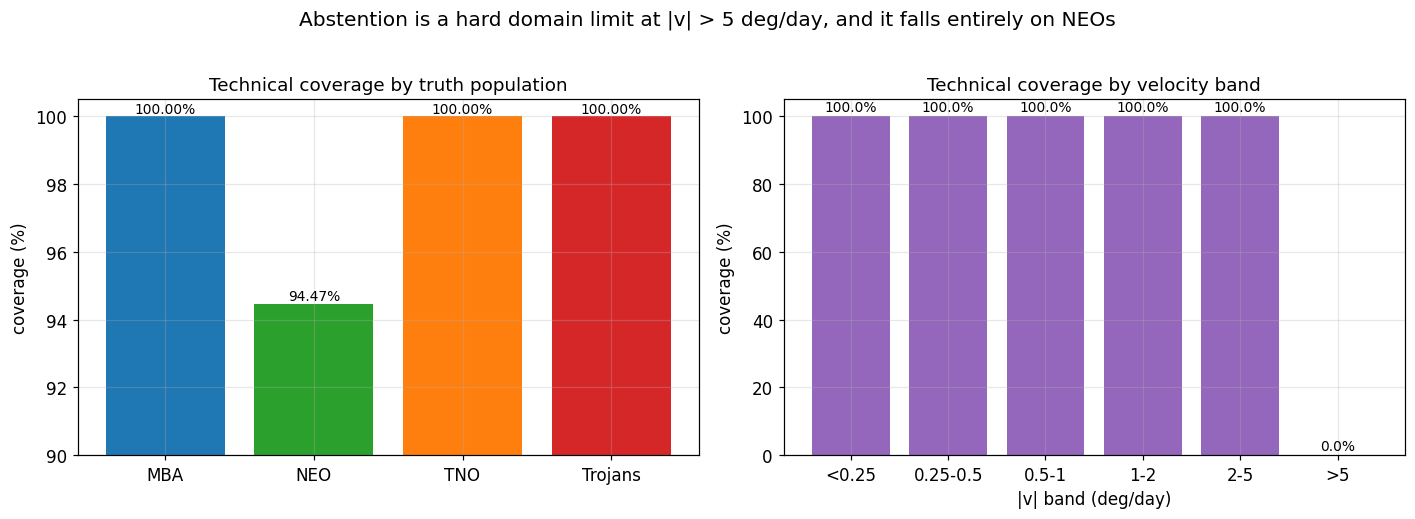

In [6]:
fig, ax = plt.subplots(1,2, figsize=(13,4.6))
t = ex.groupby("truth").common.mean()*100
ax[0].bar(t.index, t.values, color=["tab:blue","tab:green","tab:orange","tab:red"])
ax[0].set_ylim(90,100.5); ax[0].set_ylabel("coverage (%)"); ax[0].set_title("Technical coverage by truth population")
for i,(k,v) in enumerate(t.items()): ax[0].text(i, v+0.1, f"{v:.2f}%", ha="center", fontsize=9)
vb = pd.cut(vmax, [0,0.25,0.5,1,2,5,1e3],
            labels=["<0.25","0.25-0.5","0.5-1","1-2","2-5",">5"])
cv = pd.DataFrame({"vb":vb,"c":common}).groupby("vb",observed=True).c.mean()*100
ax[1].bar(cv.index.astype(str), cv.values, color="tab:purple")
ax[1].set_ylabel("coverage (%)"); ax[1].set_xlabel("|v| band (deg/day)")
ax[1].set_title("Technical coverage by velocity band")
for i,v in enumerate(cv.values): ax[1].text(i, v+1.5, f"{v:.1f}%", ha="center", fontsize=9)
fig.suptitle("Abstention is a hard domain limit at |v| > 5 deg/day, and it falls entirely on NEOs", y=1.02)
fig.tight_layout(); plt.show()

## 5. VDP calibration — raw vs Platt

Platt is **strictly monotonic** (`a = exp(alpha) > 0`), so it changes probabilities but **cannot**
change ranking. ROC AUC is therefore identical before and after; that is verified, not assumed.

In [7]:
yv = y[common]; pr_ = raw[common]; pc = vdp[common]; vv = vmax[common]
EPS = 1e-15
def ece_wilson(yy, pp, nb=15):
    edges = np.linspace(0,1,nb+1); idx = np.clip(np.digitize(pp, edges)-1, 0, nb-1)
    tot, rows = 0.0, []
    for b in range(nb):
        s = idx==b
        if not s.any(): continue
        n=int(s.sum()); o=float(yy[s].mean()); c=float(pp[s].mean()); tot += s.mean()*abs(o-c)
        z=1.959963985; d=1+z*z/n; ctr=(o+z*z/(2*n))/d
        h=z/d*np.sqrt(o*(1-o)/n + z*z/(4*n*n))
        rows.append(dict(bin=b, n=n, pred=c, obs=o, lo=max(0,ctr-h), hi=min(1,ctr+h)))
    return tot, pd.DataFrame(rows)
rows=[]
for nm, p_ in [("raw", pr_), ("calibrated (Platt)", pc)]:
    e,_ = ece_wilson(yv, np.clip(p_,EPS,1-EPS))
    rows.append(dict(scores=nm, Brier=brier_score_loss(yv,np.clip(p_,0,1)),
                     log_loss=log_loss(yv,np.clip(p_,EPS,1-EPS)), ECE=e,
                     ROC_AUC=roc_auc_score(yv,p_)))
calib = pd.DataFrame(rows)
print(calib.to_string(index=False, float_format=lambda z:f"{z:,.6g}"))
dROC = abs(calib.ROC_AUC.iloc[0]-calib.ROC_AUC.iloc[1])
print(f"\nROC AUC change under Platt: {dROC:.3e}  -> ranking preserved (strictly monotonic)")
assert dROC < 1e-12
print(f"ECE improves {calib.ECE.iloc[0]/calib.ECE.iloc[1]:.1f}x  ({calib.ECE.iloc[0]:.3e} -> {calib.ECE.iloc[1]:.3e})")

            scores      Brier  log_loss         ECE  ROC_AUC
               raw 0.00239134 0.0123026  0.00161397 0.962879
calibrated (Platt) 0.00208256 0.0113605 0.000355251 0.962879

ROC AUC change under Platt: 0.000e+00  -> ranking preserved (strictly monotonic)
ECE improves 4.5x  (1.614e-03 -> 3.553e-04)


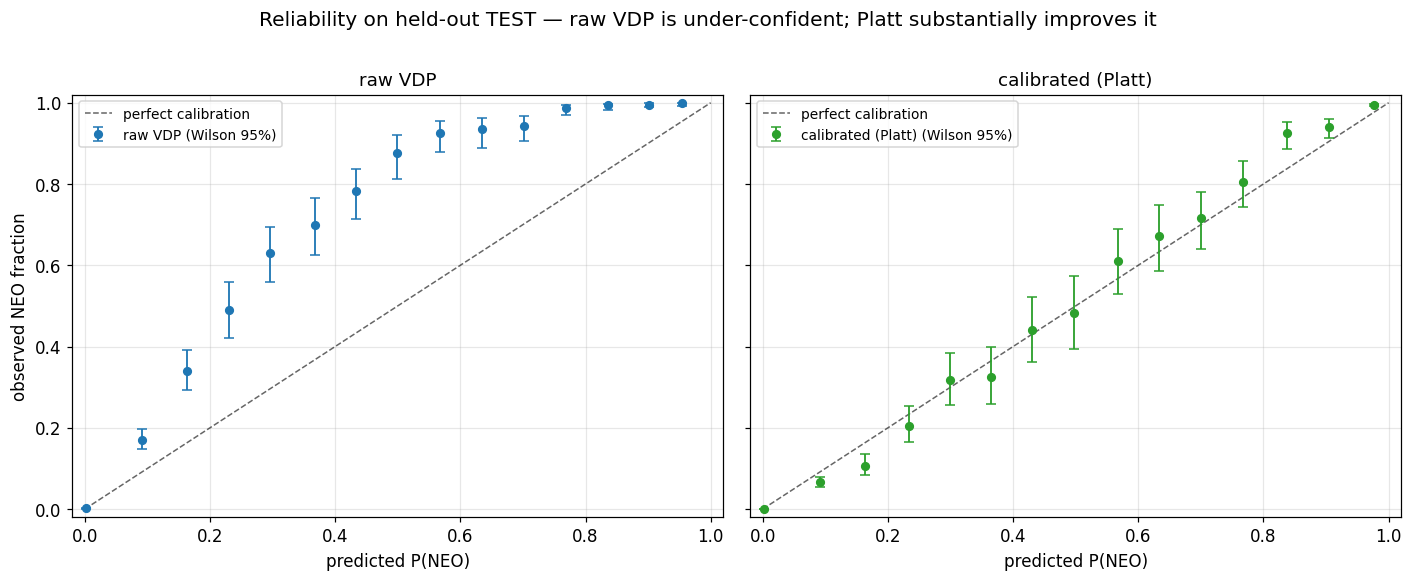

In [8]:
_, rel_raw = ece_wilson(yv, np.clip(pr_,EPS,1-EPS))
_, rel_cal = ece_wilson(yv, np.clip(pc,EPS,1-EPS))
fig, ax = plt.subplots(1,2, figsize=(13,5.2), sharex=True, sharey=True)
for a_, r, nm, col in [(ax[0],rel_raw,"raw VDP","tab:blue"),(ax[1],rel_cal,"calibrated (Platt)","tab:green")]:
    a_.plot([0,1],[0,1],"k--",lw=1,alpha=.6,label="perfect calibration")
    a_.errorbar(r.pred, r.obs, yerr=[r.obs-r.lo, r.hi-r.obs], fmt="o", color=col,
                ms=5, capsize=3, lw=1.2, label=f"{nm} (Wilson 95%)")
    a_.set_xlabel("predicted P(NEO)"); a_.set_title(nm); a_.legend(loc="upper left")
    a_.set_xlim(-0.02,1.02); a_.set_ylim(-0.02,1.02)
ax[0].set_ylabel("observed NEO fraction")
fig.suptitle("Reliability on held-out TEST — raw VDP is under-confident; Platt substantially improves it", y=1.01)
fig.tight_layout(); plt.show()

## 6. Paired VDP vs digest2 on identical rows

Both classifiers are restricted to the **same** 643,499 common scorable rows. The bootstrap is
truth-stratified with a fixed seed.

> digest2 emits a **heuristic score**, not a calibrated probability. Its Brier and log loss are
> therefore **not** presented as an equivalent probability-calibration comparison — only ranking
> metrics are compared like-for-like.

In [9]:
pd2 = d2[common]
def rank_metrics(s):
    p_,r_,_ = precision_recall_curve(yv, s)
    f1 = np.divide(2*p_*r_, p_+r_, out=np.zeros_like(p_), where=(p_+r_)>0)
    return dict(ROC_AUC=roc_auc_score(yv,s), stdpAUC_fpr01=roc_auc_score(yv,s,max_fpr=0.01),
                maxF1=float(f1[:-1].max()))
mv, md = rank_metrics(pc), rank_metrics(pd2)
tabm = pd.DataFrame([{"classifier":"VDP (variant C + Platt)", **mv,
                      "Brier":brier_score_loss(yv,np.clip(pc,0,1)),
                      "log_loss":log_loss(yv,np.clip(pc,EPS,1-EPS))},
                     {"classifier":"digest2 (repeatable)", **md, "Brier":np.nan, "log_loss":np.nan}])
print("ranking metrics on identical rows (digest2 Brier/log loss intentionally omitted):")
print(tabm.to_string(index=False, float_format=lambda z:f"{z:,.6g}"))
EXPECT = {"VDP":dict(ROC_AUC=0.962879, stdpAUC_fpr01=0.908296, maxF1=0.822069,
                     Brier=0.00208256, log_loss=0.0113605),
          "D2":dict(ROC_AUC=0.957919, stdpAUC_fpr01=0.868333, maxF1=0.737074)}
for k,v in EXPECT["VDP"].items():
    got_ = tabm.iloc[0][k]; assert abs(got_-v) < 5e-6, f"VDP {k}: {got_} vs {v}"
for k,v in EXPECT["D2"].items():
    got_ = tabm.iloc[1][k]; assert abs(got_-v) < 5e-6, f"digest2 {k}: {got_} vs {v}"
print("\nall frozen values reproduced within 5e-6")

ranking metrics on identical rows (digest2 Brier/log loss intentionally omitted):
             classifier  ROC_AUC  stdpAUC_fpr01    maxF1      Brier  log_loss
VDP (variant C + Platt) 0.962879       0.908296 0.822069 0.00208256 0.0113605
   digest2 (repeatable) 0.957919       0.868333 0.737074        NaN       NaN

all frozen values reproduced within 5e-6


In [10]:
rng = np.random.default_rng(0)   # same seed as the frozen run
i1, i0 = np.where(yv==1)[0], np.where(yv==0)[0]
D = {k:[] for k in ["ROC_AUC","stdpAUC_fpr01","maxF1"]}
for _ in range(500):
    b = np.concatenate([rng.choice(i1,len(i1),True), rng.choice(i0,len(i0),True)])
    yy, a_, c_ = yv[b], pc[b], pd2[b]
    if yy.sum() < 5: continue
    D["ROC_AUC"].append(roc_auc_score(yy,a_)-roc_auc_score(yy,c_))
    D["stdpAUC_fpr01"].append(roc_auc_score(yy,a_,max_fpr=0.01)-roc_auc_score(yy,c_,max_fpr=0.01))
    def f1o(t):
        p_,r_,_ = precision_recall_curve(yy,t)
        f = np.divide(2*p_*r_, p_+r_, out=np.zeros_like(p_), where=(p_+r_)>0); return f[:-1].max()
    D["maxF1"].append(f1o(a_)-f1o(c_))
boot = pd.DataFrame([dict(metric=k, difference=mv[k]-md[k], ci_lo=np.percentile(v,2.5),
                          ci_hi=np.percentile(v,97.5),
                          excludes_zero=bool(np.percentile(v,2.5)>0 or np.percentile(v,97.5)<0))
                     for k,v in D.items()])
print("paired truth-stratified bootstrap, B=500, VDP - digest2:")
print(boot.to_string(index=False, float_format=lambda z:f"{z:,.6f}"))
frozen = json.loads(REQUIRED["TEST_COMPARISON"].read_text())
fz = {r["metric"]:r for r in frozen["paired"]}
print("\nagreement with the frozen comparison JSON:")
for _, r in boot.iterrows():
    f_ = fz[r.metric]
    print(f"  {r.metric:16s} notebook {r.difference:+.6f}  frozen {f_['point']:+.6f}  "
          f"|d|={abs(r.difference-f_['point']):.2e}")
    assert abs(r.difference-f_["point"]) < 5e-6
print("\nall paired differences reproduce; all three CIs exclude zero:",
      bool(boot.excludes_zero.all()))

paired truth-stratified bootstrap, B=500, VDP - digest2:
       metric  difference    ci_lo    ci_hi  excludes_zero
      ROC_AUC    0.004960 0.001194 0.008842           True
stdpAUC_fpr01    0.039963 0.035843 0.044897           True
        maxF1    0.084995 0.076562 0.095201           True

agreement with the frozen comparison JSON:
  ROC_AUC          notebook +0.004960  frozen +0.004960  |d|=0.00e+00
  stdpAUC_fpr01    notebook +0.039963  frozen +0.039963  |d|=0.00e+00
  maxF1            notebook +0.084995  frozen +0.084995  |d|=0.00e+00

all paired differences reproduce; all three CIs exclude zero: True


## 7. Figures

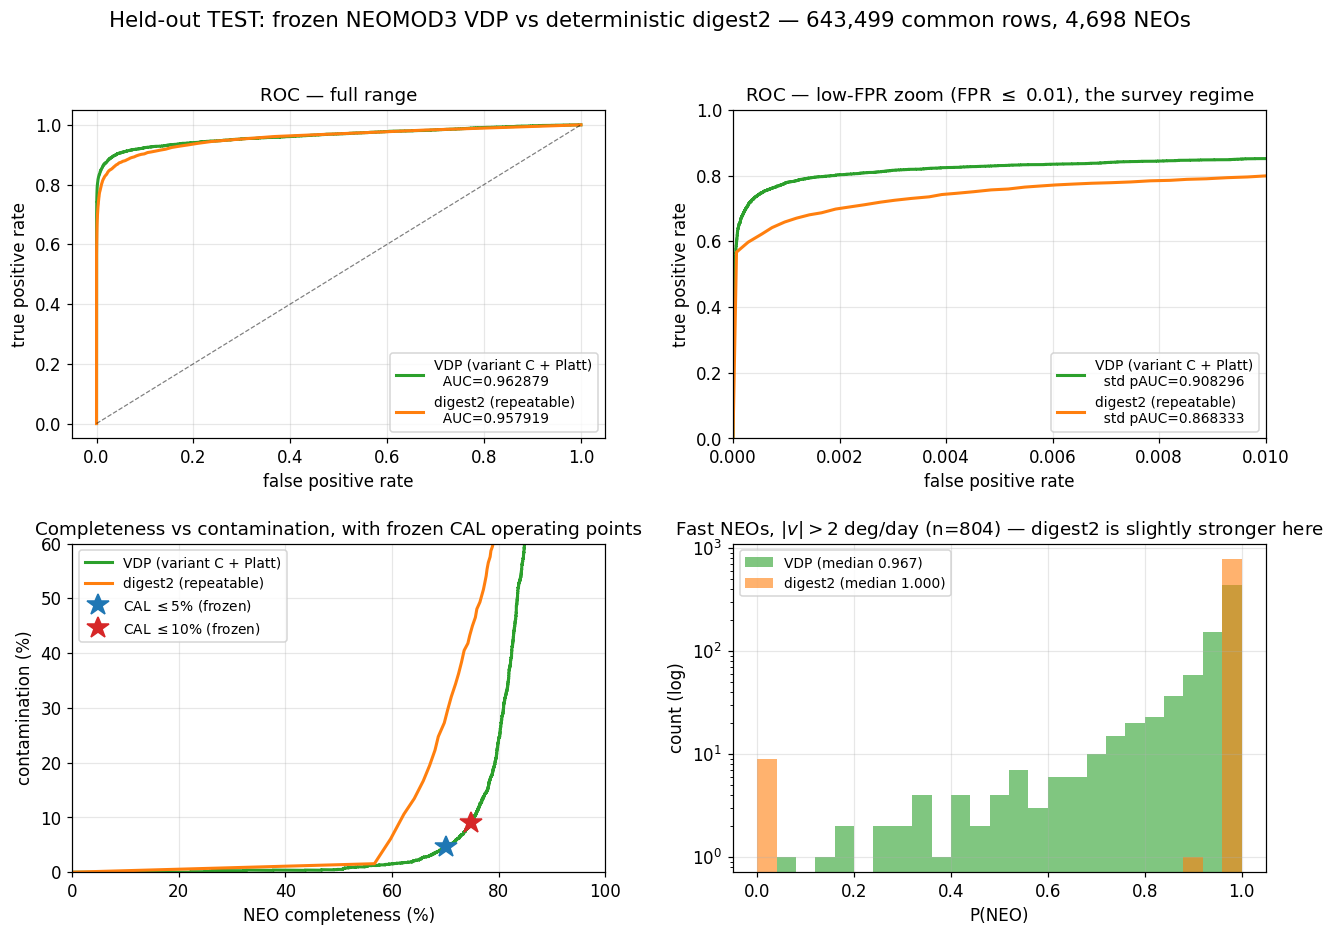

In [11]:
fig = plt.figure(figsize=(14,9))
gs = fig.add_gridspec(2,2, hspace=0.32, wspace=0.24)
series = [(pc,"VDP (variant C + Platt)","tab:green"), (pd2,"digest2 (repeatable)","tab:orange")]
ax = fig.add_subplot(gs[0,0])
for s_,nm,c in series:
    fpr,tpr,_ = roc_curve(yv,s_); ax.plot(fpr,tpr,lw=2,color=c,label=f"{nm}\n  AUC={roc_auc_score(yv,s_):.6f}")
ax.plot([0,1],[0,1],"k--",lw=.8,alpha=.5); ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate"); ax.set_title("ROC — full range"); ax.legend(loc="lower right")
ax = fig.add_subplot(gs[0,1])
for s_,nm,c in series:
    fpr,tpr,_ = roc_curve(yv,s_)
    ax.plot(fpr,tpr,lw=2,color=c,label=f"{nm}\n  std pAUC={roc_auc_score(yv,s_,max_fpr=0.01):.6f}")
ax.set_xlim(0,0.01); ax.set_ylim(0,1); ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate"); ax.set_title("ROC — low-FPR zoom (FPR $\\leq$ 0.01), the survey regime")
ax.legend(loc="lower right")
ax = fig.add_subplot(gs[1,0])
for s_,nm,c in series:
    p_,r_,_ = precision_recall_curve(yv,s_); ax.plot(r_*100,(1-p_)*100,lw=2,color=c,label=nm)
for t_,lab,c in [(SEAL["operating_thresholds_from_CAL"]["contamination_le_5pct"],"CAL $\\leq$5%","tab:blue"),
                 (SEAL["operating_thresholds_from_CAL"]["contamination_le_10pct"],"CAL $\\leq$10%","tab:red")]:
    sel = pc>=t_; tp=int((sel&(yv==1)).sum()); fp=int((sel&(yv==0)).sum())
    ax.plot(100*tp/yv.sum(), 100*fp/max(tp+fp,1), "*", ms=15, color=c, label=f"{lab} (frozen)")
ax.set_xlabel("NEO completeness (%)"); ax.set_ylabel("contamination (%)")
ax.set_xlim(0,100); ax.set_ylim(0,60); ax.set_title("Completeness vs contamination, with frozen CAL operating points")
ax.legend(loc="upper left")
ax = fig.add_subplot(gs[1,1])
f_ = (vv>2)&(yv==1)
bins = np.linspace(0,1,26)
ax.hist(pc[f_], bins=bins, alpha=.6, color="tab:green", label=f"VDP (median {np.median(pc[f_]):.3f})")
ax.hist(pd2[f_], bins=bins, alpha=.6, color="tab:orange", label=f"digest2 (median {np.median(pd2[f_]):.3f})")
ax.set_yscale("log"); ax.set_xlabel("P(NEO)"); ax.set_ylabel("count (log)")
ax.set_title(f"Fast NEOs, $|v|>2$ deg/day (n={int(f_.sum())}) — digest2 is slightly stronger here")
ax.legend()
fig.suptitle("Held-out TEST: frozen NEOMOD3 VDP vs deterministic digest2 — "
             f"{len(yv):,} common rows, {int(yv.sum()):,} NEOs", fontsize=14, y=0.98)
plt.show()

## 8. Frozen operating points

The CAL thresholds are applied to TEST **unchanged**. Best-F1 is shown only as a descriptive TEST
diagnostic — it was **not** used to choose anything.

In [12]:
rows=[]
for nm,t_,note in [("best-F1", thr["best_F1_DIAGNOSTIC_ONLY"], "TEST diagnostic only — NOT tuned"),
                   ("CAL contamination <= 5%", thr["contamination_le_5pct"], "frozen on CAL"),
                   ("CAL contamination <= 10%", thr["contamination_le_10pct"], "frozen on CAL")]:
    sel = pc>=t_; tp=int((sel&(yv==1)).sum()); fp=int((sel&(yv==0)).sum())
    rows.append(dict(rule=nm, threshold=t_, completeness_pct=100*tp/yv.sum(),
                     contamination_pct=100*fp/max(tp+fp,1), TP=tp, FP=fp, provenance=note))
ops = pd.DataFrame(rows)
print(ops.to_string(index=False, float_format=lambda z:f"{z:,.6g}"))
for t_,ec,ek in [(thr["contamination_le_5pct"],4.55072,70.0937),(thr["contamination_le_10pct"],8.94478,74.7552)]:
    r = ops[np.isclose(ops.threshold,t_)].iloc[0]
    assert abs(r.contamination_pct-ec)<5e-4 and abs(r.completeness_pct-ek)<5e-4
print("\nfrozen operating points reproduce exactly.")
print("NO TEST THRESHOLD WAS TUNED: both thresholds were fixed on CAL before TEST was drawn,")
print("and both land UNDER their CAL targets (4.55% vs 5%, 8.94% vs 10%) on unseen data.")

                    rule  threshold  completeness_pct  contamination_pct   TP  FP                       provenance
                 best-F1   0.399848           75.1809            9.50551 3532 371 TEST diagnostic only — NOT tuned
 CAL contamination <= 5%   0.629311           70.0937            4.55072 3293 157                    frozen on CAL
CAL contamination <= 10%   0.417245           74.7552            8.94478 3512 345                    frozen on CAL

frozen operating points reproduce exactly.
NO TEST THRESHOLD WAS TUNED: both thresholds were fixed on CAL before TEST was drawn,
and both land UNDER their CAL targets (4.55% vs 5%, 8.94% vs 10%) on unseen data.


## 9. Interpretation

**On the 643,499 held-out TEST tracklets scored by both methods, VDP outperforms deterministic
digest2 in ROC AUC, low-FPR partial AUC, and maximum F1.** All three paired bootstrap intervals
exclude zero.

Two caveats belong with that sentence:

1. **The conclusion is conditional on the common scorable set.** VDP abstains on **275 fast NEOs
   beyond ±5 deg/day**, which digest2 scores. Those rows are excluded from both arms. Counting them
   as VDP misses would lower end-to-end NEO recovery.
2. **digest2 is slightly stronger on fast NEOs**, and this benchmark has **perfect astrometry**.
   digest2 is built for real, noisy short arcs, so it is not being tested in the regime it was
   designed for. Noisy-tracklet and operational (Sorcha/LSST) testing remain separate future work.

In [13]:
f_ = (vv>2)&(yv==1)
print(f"fast NEOs (|v| > 2 deg/day) on the common set: n = {int(f_.sum())}")
print(f"  VDP     median {np.median(pc[f_]):.4f}   frac >= 0.5 {100*np.mean(pc[f_]>=0.5):.1f}%")
print(f"  digest2 median {np.median(pd2[f_]):.4f}   frac >= 0.5 {100*np.mean(pd2[f_]>=0.5):.1f}%")
print(f"\nNEOs excluded from BOTH arms (|v| > 5, VDP domain limit): 275")
print(f"  end-to-end NEO recovery at the CAL <=5% threshold, counting abstentions as misses:")
sel = pc>=thr["contamination_le_5pct"]; tp=int((sel&(yv==1)).sum())
print(f"    conditional (common set)  {100*tp/yv.sum():.2f}%   ({tp}/{int(yv.sum())})")
print(f"    end-to-end (all TEST NEOs) {100*tp/4973:.2f}%   ({tp}/4973)")

fast NEOs (|v| > 2 deg/day) on the common set: n = 804
  VDP     median 0.9666   frac >= 0.5 97.3%
  digest2 median 1.0000   frac >= 0.5 98.9%

NEOs excluded from BOTH arms (|v| > 5, VDP domain limit): 275
  end-to-end NEO recovery at the CAL <=5% threshold, counting abstentions as misses:
    conditional (common set)  70.09%   (3293/4698)
    end-to-end (all TEST NEOs) 66.22%   (3293/4973)


## 10. Summary for review

In [14]:
summary = pd.DataFrame([
 ["Held-out TEST rows scored by both", f"{len(yv):,}"],
 ["NEOs in the common set", f"{int(yv.sum()):,}   (prior {100*yv.mean():.4f}%)"],
 ["VDP ROC AUC", f"{mv['ROC_AUC']:.6f}"],
 ["digest2 ROC AUC", f"{md['ROC_AUC']:.6f}"],
 ["VDP std. partial AUC (FPR<=0.01)", f"{mv['stdpAUC_fpr01']:.6f}"],
 ["digest2 std. partial AUC", f"{md['stdpAUC_fpr01']:.6f}"],
 ["VDP max F1", f"{mv['maxF1']:.6f}"],
 ["digest2 max F1", f"{md['maxF1']:.6f}"],
 ["VDP calibrated Brier / log loss / ECE",
  f"{calib.Brier.iloc[1]:.3e} / {calib.log_loss.iloc[1]:.3e} / {calib.ECE.iloc[1]:.3e}"],
 ["Frozen CAL <=5% threshold on TEST", "70.09% completeness @ 4.55% contamination"],
 ["Frozen CAL <=10% threshold on TEST", "74.76% completeness @ 8.94% contamination"],
 ["NEO technical coverage", "94.47%  (275/4,973 abstained, all |v| > 5 deg/day)"],
], columns=["quantity","value"])
print(summary.to_string(index=False))

                             quantity                                              value
    Held-out TEST rows scored by both                                            643,499
               NEOs in the common set                            4,698   (prior 0.7301%)
                          VDP ROC AUC                                           0.962879
                      digest2 ROC AUC                                           0.957919
     VDP std. partial AUC (FPR<=0.01)                                           0.908296
             digest2 std. partial AUC                                           0.868333
                           VDP max F1                                           0.822069
                       digest2 max F1                                           0.737074
VDP calibrated Brier / log loss / ECE                  2.083e-03 / 1.136e-02 / 3.553e-04
    Frozen CAL <=5% threshold on TEST          70.09% completeness @ 4.55% contamination
   Frozen CAL <=10% t

### What changed from the old S3M VDP?

| | old production VDP | frozen NEOMOD3 VDP |
|---|---|---|
| NEO population | S3M (H < 25) | **NEOMOD3** (H 15–28), absolute normalisation |
| non-NEO cloning | MBA/TNO/Trojans GMM-cloned | **not cloned** — real Stage-0 objects |
| velocity domain | ±2 deg/day | **±5 deg/day** |
| support handling | per-pixel occupancy mask, NEO exempt | **symmetric unmasked densities**; technical-only abstention |
| magnitude | hard bin edges | **continuous interpolation between bins** |
| output | uncalibrated ratio | **Platt-calibrated probability**, prior kept separable |
| evaluation | scored on maps' own objects | **GEN/CAL/TEST split**, no lineage crossing |

The occupancy mask was the single largest defect: it was resolution-dependent, and removing it
changed pAUC on CAL from 0.8867 to 0.9535.

### What we can and cannot claim

**Can claim**
- On this held-out, population-matched geometric benchmark, the frozen VDP ranks NEOs better than
  deterministic digest2 — ROC AUC, low-FPR partial AUC and max F1, all with paired CIs excluding zero.
- Calibrated probabilities are well behaved out of sample (ECE 3.55e-04) and thresholds fixed on CAL
  transferred to TEST **under** their targets.
- The prior is separable, so the probability can be re-expressed for a different NEO prior under a
  stated label-shift assumption.

**Cannot claim**
- Any operational LSST result. No measurement noise, footprint, detection efficiency, trailing loss
  or linking is modelled here.
- Superiority on fast movers: digest2 is slightly stronger at |v| > 2, and VDP abstains beyond ±5.
- That digest2 is worse as a probability: it is a heuristic score and was never calibrated here.